In [122]:
import cv2

img = cv2.imread("differences/3.Solution.jpeg")
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)


lower_red1 = np.array([0, 120, 70])
upper_red1 = np.array([10, 255, 255])

lower_red2 = np.array([170, 120, 70])
upper_red2 = np.array([180, 255, 255])

mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
mask2 = cv2.inRange(hsv, lower_red2, upper_red2)



mask = mask1 + mask2


In [123]:
cv2.imshow("Mask", mask)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [124]:
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

centers = []

for cnt in contours:
    M = cv2.moments(cnt)
    if M["m00"] != 0:
        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])
        centers.append((cx, cy))

In [125]:
centers


[(374, 438), (82, 392), (516, 310), (518, 162), (278, 101)]

In [126]:
for (cx, cy) in centers:
    cv2.circle(img, (cx, cy), 10, (255, 255, 255), -1)  # blue filled circle

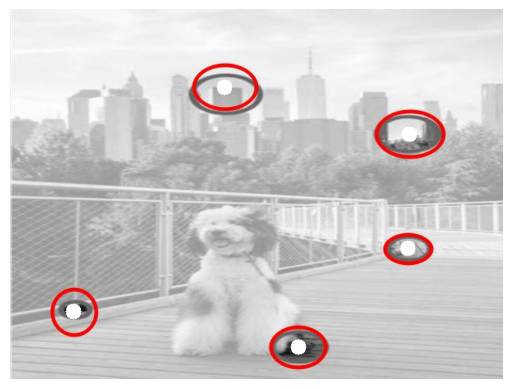

In [127]:
import matplotlib.pyplot as plt

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

In [45]:
def get_centers()

SyntaxError: expected ':' (4213737729.py, line 1)

In [96]:
import cv2
import numpy as np
from scipy.spatial.distance import cdist

# Load and process images
img1 = cv2.imread("16.Left.jpeg")
img2 = cv2.imread("16.Right.jpeg")

gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

diff = cv2.absdiff(gray1, gray2)
_, thresh = cv2.threshold(diff, 30, 255, cv2.THRESH_BINARY)

kernel = np.ones((5,5), np.uint8)
thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

# Get individual difference contours (ungrouped)
contours_individual, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Function to check if two circles overlap
def circles_overlap(circle1, circle2):
    """circle = (center_x, center_y, radius)"""
    (x1, y1, r1) = circle1
    (x2, y2, r2) = circle2
    distance = np.sqrt((x1 - x2)**2 + (y1 - y2)**2)
    return distance < (r1 + r2)  # Overlap if distance less than sum of radii

# Function to merge overlapping circles
def merge_overlapping_circles(circles):
    """Merge circles that overlap with each other"""
    if len(circles) == 0:
        return []
    
    # Convert to list of tuples for easier handling
    circles = [(int(x), int(y), int(r)) for (x, y, r) in circles]
    
    # Group overlapping circles
    merged = []
    used = [False] * len(circles)
    
    for i in range(len(circles)):
        if not used[i]:
            # Start a new group with circle i
            group = [circles[i]]
            used[i] = True
            
            # Keep merging while we find new overlaps
            changed = True
            while changed:
                changed = False
                for j in range(len(circles)):
                    if not used[j]:
                        # Check if circle j overlaps with any circle in group
                        for circle in group:
                            if circles_overlap(circle, circles[j]):
                                group.append(circles[j])
                                used[j] = True
                                changed = True
                                break
            
            # Merge all circles in group into one larger circle
            if len(group) > 1:
                # Calculate bounding box that covers all circles in group
                min_x = min([c[0] - c[2] for c in group])
                min_y = min([c[1] - c[2] for c in group])
                max_x = max([c[0] + c[2] for c in group])
                max_y = max([c[1] + c[2] for c in group])
                
                # Create a bounding circle
                center_x = (min_x + max_x) // 2
                center_y = (min_y + max_y) // 2
                radius = max(center_x - min_x, center_y - min_y) + 5  # Add padding
                merged.append((center_x, center_y, radius))
            else:
                merged.append(group[0])
    
    return merged

# First, create individual circles from contours
initial_circles = []
for cnt in contours_individual:
    (x, y), radius = cv2.minEnclosingCircle(cnt)
    center = (int(x), int(y))
    radius = max(10, int(radius) + 5)
    initial_circles.append((center[0], center[1], radius))

# Merge overlapping circles
final_circles = merge_overlapping_circles(initial_circles)

# Create output image
_, bw = cv2.threshold(gray1, 127, 255, cv2.THRESH_BINARY)
output = cv2.cvtColor(bw, cv2.COLOR_GRAY2BGR)

# Draw final merged circles
for (x, y, r) in final_circles:
    cv2.circle(output, (x, y), r, (0, 0, 255), 2)
    # Optional: Add text showing it's a merged region
    # cv2.putText(output, f"Area: {r}", (x-20, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

print(f"Initial circles: {len(initial_circles)}")
print(f"Merged circles: {len(final_circles)}")

cv2.imshow("Merged Circles (Overlap Detection)", output)
cv2.waitKey(0)
cv2.destroyAllWindows()

Initial circles: 120
Merged circles: 36


In [78]:
import os
import re

def get_image_pairs(folder_path):
    """
    Extract paired left and right images from a folder.
    Returns a list of tuples: [(left_filename, right_filename, pair_number), ...]
    """
    # Get all files in the folder
    all_files = os.listdir(folder_path)
    
    # Dictionary to store pairs
    pairs = {}
    
    # Pattern to match filename format: number.left/right.jpeg
    pattern = re.compile(r'(\d+)\.(left|right)\.jpe?g$', re.IGNORECASE)
    
    for filename in all_files:
        match = pattern.match(filename)
        if match:
            number = int(match.group(1))
            side = match.group(2).lower()
            
            # Initialize dictionary for this number if not exists
            if number not in pairs:
                pairs[number] = {'left': None, 'right': None}
            
            # Assign the filename to the appropriate side
            pairs[number][side] = filename
    
    # Filter out incomplete pairs and convert to list
    image_pairs = []
    for number in sorted(pairs.keys()):
        if pairs[number]['left'] is not None and pairs[number]['right'] is not None:
            image_pairs.append((pairs[number]['left'], pairs[number]['right'], number))
        else:
            print(f"Warning: Incomplete pair for number {number} (missing {pairs[number]})")
    
    return image_pairs

# Usage example:
folder_path = "."  # Current directory, or specify your folder path
image_pairs = get_image_pairs(folder_path)


In [68]:
image_pairs[0][0]

'1.Left.jpeg'

Initial circles: 14
Final circles (merged): 5
Saved: ./mohamed/2.Solution.jpeg


Initial circles: 219
Final circles (merged): 12
Saved: ./mohamed/1.Solution.jpeg
Initial circles: 14
Final circles (merged): 5
Saved: ./mohamed/2.Solution.jpeg
Initial circles: 21
Final circles (merged): 18
Saved: ./mohamed/3.Solution.jpeg
Initial circles: 88
Final circles (merged): 53
Saved: ./mohamed/4.Solution.jpeg
Initial circles: 357
Final circles (merged): 57
Saved: ./mohamed/5.Solution.jpeg
Initial circles: 15
Final circles (merged): 11
Saved: ./mohamed/6.Solution.jpeg
Initial circles: 6
Final circles (merged): 6
Saved: ./mohamed/7.Solution.jpeg
Initial circles: 6
Final circles (merged): 4
Saved: ./mohamed/8.Solution.jpeg
Initial circles: 10
Final circles (merged): 8
Saved: ./mohamed/9.Solution.jpeg
Initial circles: 12
Final circles (merged): 5
Saved: ./mohamed/10.Solution.jpeg
Initial circles: 295
Final circles (merged): 23
Saved: ./mohamed/11.Solution.jpeg
Initial circles: 33
Final circles (merged): 19
Saved: ./mohamed/12.Solution.jpeg
Initial circles: 16
Final circles (merged

In [97]:
# turn image into black and white
import os
from PIL import Image

INPUT_FOLDER = "/home/mohamed/Documents/mohamed/madrasat_zaman/assets/images/diff/mohamed/solutions"
OUTPUT_FOLDER = "/home/mohamed/Documents/mohamed/madrasat_zaman/assets/images/diff/difrrences"

os.makedirs(OUTPUT_FOLDER, exist_ok=True)

VALID_EXT = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

for filename in os.listdir(INPUT_FOLDER):
    if not filename.lower().endswith(VALID_EXT):
        continue

    input_path = os.path.join(INPUT_FOLDER, filename)
    output_path = os.path.join(OUTPUT_FOLDER, filename)

    try:
        img = Image.open(input_path)

        # convert to grayscale (black & white)
        bw_img = img.convert("L")

        bw_img.save(output_path)

        print(f"Converted: {filename}")

    except Exception as e:
        print(f"Error with {filename}: {e}")

Converted: 14.Solution.jpeg
Converted: 28.Solution.jpeg
Converted: 23.Solution.jpeg
Converted: 9.Solution.jpeg
Converted: 7.Solution.jpeg
Converted: 26.Solution.jpeg
Converted: 13.Solution.jpeg
Converted: 8.Solution.jpeg
Converted: 29.Solution.jpeg
Converted: 22.Solution.jpeg
Converted: 3.Solution.jpeg
Converted: 1.Solution.jpeg
Converted: 11.Solution.jpeg
Converted: 6.Solution.jpeg
Converted: 17.Solution.jpeg
Converted: 12.Solution.jpeg
Converted: 18.Solution.jpeg
Converted: 27.Solution.jpeg
Converted: 16.Solution.jpeg
Converted: 4.Solution.jpeg
Converted: 30.Solution.jpeg
Converted: 24.Solution.jpeg
Converted: 20.Solution.jpeg
Converted: 25.Solution.jpeg
Converted: 10.Solution.jpeg
Converted: 2.Solution.jpeg
Converted: 15.Solution.jpeg
Converted: 21.Solution.jpeg
Converted: 31.Solution.jpeg
Converted: 5.Solution.jpeg
Converted: 19.Solution.jpeg
